In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv(r"C:\Users\itsmy\Downloads\Indian Liver Patient Dataset (ILPD).csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\itsmy\\Downloads\\Indian Liver Patient Dataset (ILPD).csv'

In [6]:
# Standard column names for the ILPD dataset
columns = [
    'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
    'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
    'Albumin_and_Globulin_Ratio', 'Target'
]

# Load the dataset
df = pd.read_csv('/content/Indian Liver Patient Dataset (ILPD).csv', names=columns)

# Preview the first few rows
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [7]:
# Check for null values
print(df.isnull().sum())

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Target                        0
dtype: int64


In [8]:
# Fill missing values with the median of the column
df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median(), inplace=True)

/tmp/ipykernel_296/1680466689.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median(), inplace=True)


In [9]:
print("\nMissing values after fixing:")
print(df.isnull().sum())


Missing values after fixing:
Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Target                        0
dtype: int64


In [10]:
# Convert Gender to numeric (Male = 1, Female = 0)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Change Target variable from 1 & 2 to 1 (Disease) & 0 (No Disease)
df['Target'] = df['Target'].map({1: 1, 2: 0})

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [11]:
# Drop 'Gender' for math calculations since it is text
df_numeric = df.drop(columns=['Gender'])

print("--- Mean ---")
print(df_numeric.mean())

print("\n--- Median ---")
print(df_numeric.median())

print("\n--- Mode ---")
print(df_numeric.mode().iloc[0])

print("\n--- Skewness ---")
print(df_numeric.skew())

print("\n--- Kurtosis ---")
print(df_numeric.kurtosis())

--- Mean ---
Age                            44.746141
Total_Bilirubin                 3.298799
Direct_Bilirubin                1.486106
Alkaline_Phosphotase          290.576329
Alamine_Aminotransferase       80.713551
Aspartate_Aminotransferase    109.910806
Total_Protiens                  6.483190
Albumin                         3.141852
Albumin_and_Globulin_Ratio      0.946947
Target                          0.713551
dtype: float64

--- Median ---
Age                            45.00
Total_Bilirubin                 1.00
Direct_Bilirubin                0.30
Alkaline_Phosphotase          208.00
Alamine_Aminotransferase       35.00
Aspartate_Aminotransferase     42.00
Total_Protiens                  6.60
Albumin                         3.10
Albumin_and_Globulin_Ratio      0.93
Target                          1.00
dtype: float64

--- Mode ---
Age                            60.0
Total_Bilirubin                 0.8
Direct_Bilirubin                0.2
Alkaline_Phosphotase          198.0
Ala

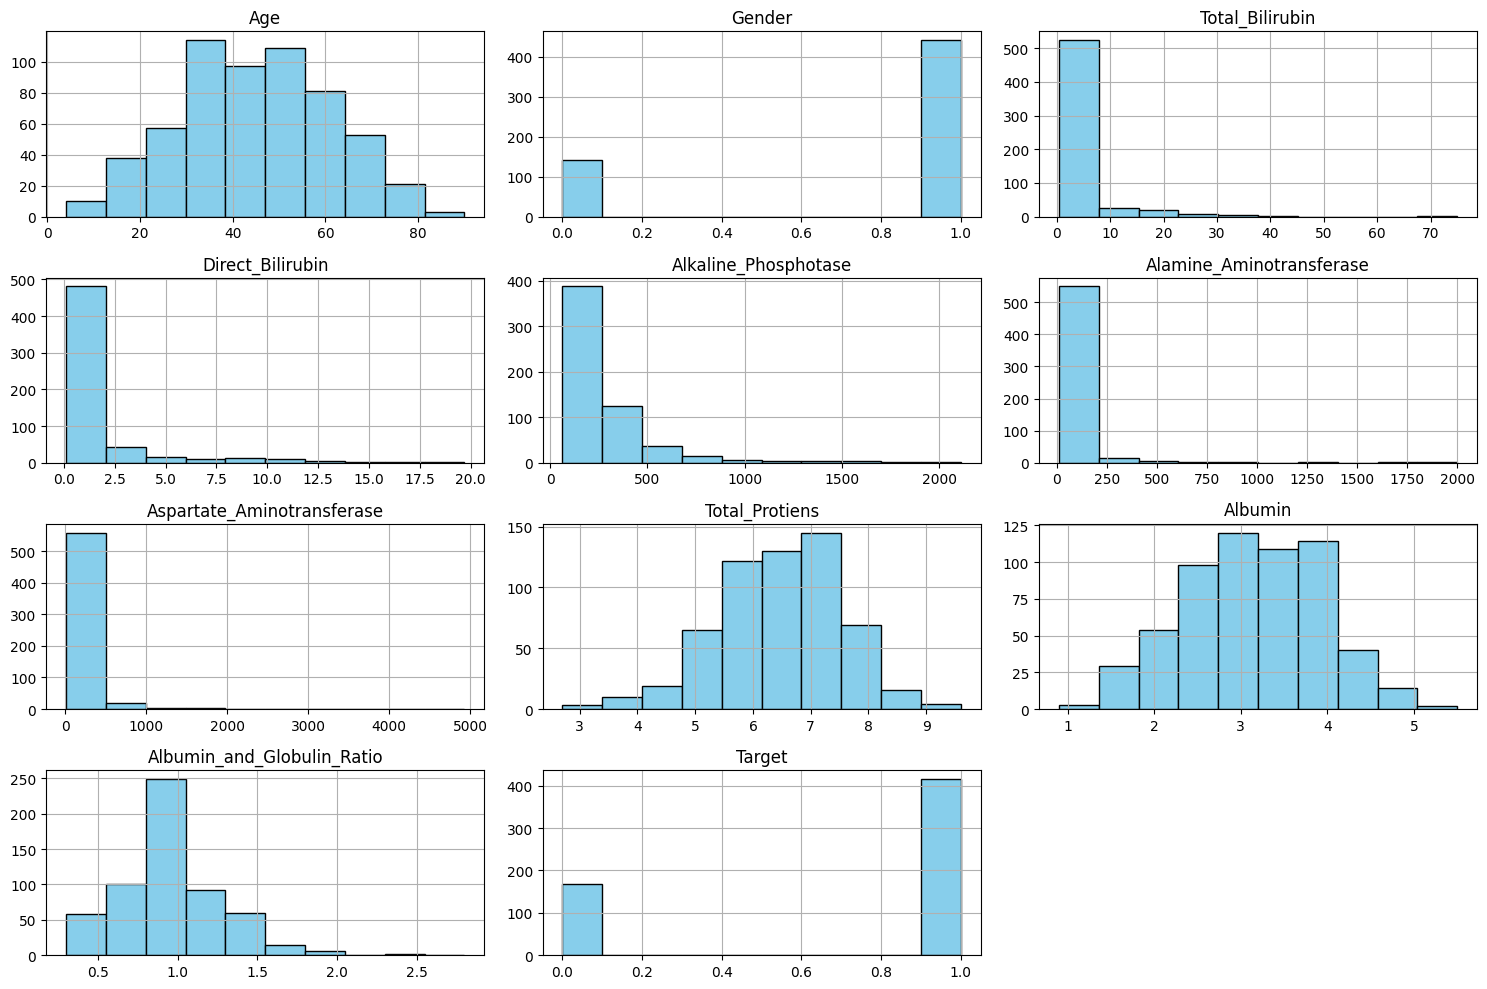

In [12]:
# Plot histograms for all numeric columns
df.hist(figsize=(15, 10), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

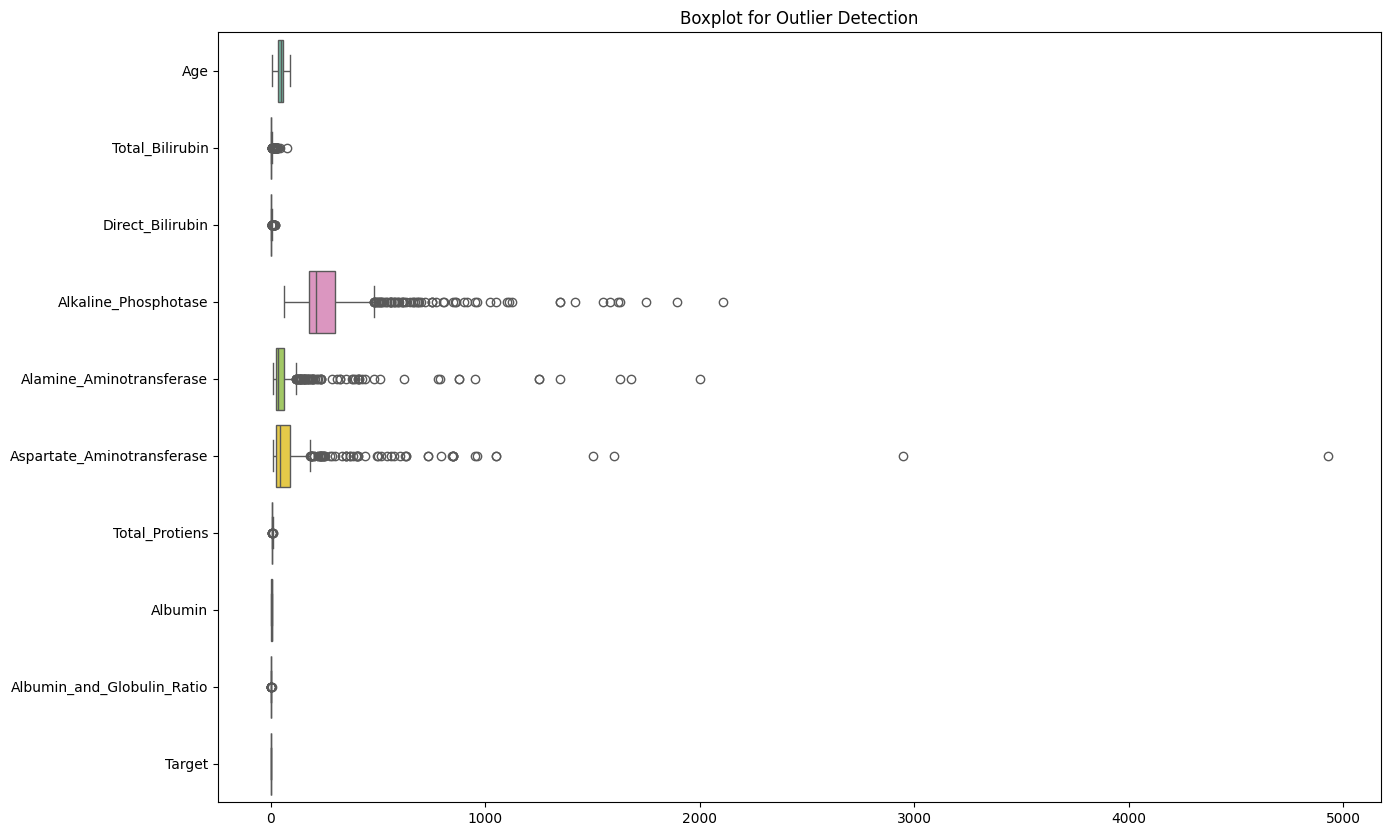

In [13]:
# Plot boxplots for all numeric columns
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_numeric, orient="h", palette="Set2")
plt.title("Boxplot for Outlier Detection")
plt.show()